In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('project_data.csv')

In [4]:
data.head(5)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,meal_plan_1,0,room_type1,224,2017-10-02,offline,0,0,0,65.00,0,not_canceled
1,INN00002,2,0,2,3,not_selected,0,room_type1,5,2018-11-06,online,0,0,0,106.68,1,not_canceled
2,INN00003,1,0,2,1,meal_plan_1,0,room_type1,1,2018-02-28,online,0,0,0,60.00,0,canceled
3,INN00004,2,0,0,2,meal_plan_1,0,room_type1,211,2018-05-20,online,0,0,0,100.00,0,canceled
4,INN00005,2,0,1,1,not_selected,0,room_type1,48,2018-04-11,online,0,0,0,94.50,0,canceled


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36238 entries, 0 to 36237
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36238 non-null  object 
 1   no_of_adults                          36238 non-null  int64  
 2   no_of_children                        36238 non-null  int64  
 3   no_of_weekend_nights                  36238 non-null  int64  
 4   no_of_week_nights                     36238 non-null  int64  
 5   type_of_meal_plan                     36238 non-null  object 
 6   required_car_parking_space            36238 non-null  int64  
 7   room_type_reserved                    36238 non-null  object 
 8   lead_time                             36238 non-null  int64  
 9   arrival_date                          36238 non-null  object 
 10  market_segment_type                   36238 non-null  object 
 11  repeated_guest 

In [11]:
quantitative = set((data.drop('Booking_ID', axis=1).describe().columns))

In [17]:
categorical = set((data.drop(['Booking_ID', 'arrival_date'], axis=1).columns)) - quantitative

In [18]:
categorical

{'booking_status',
 'market_segment_type',
 'room_type_reserved',
 'type_of_meal_plan'}

In [19]:
import matplotlib.pyplot as plt

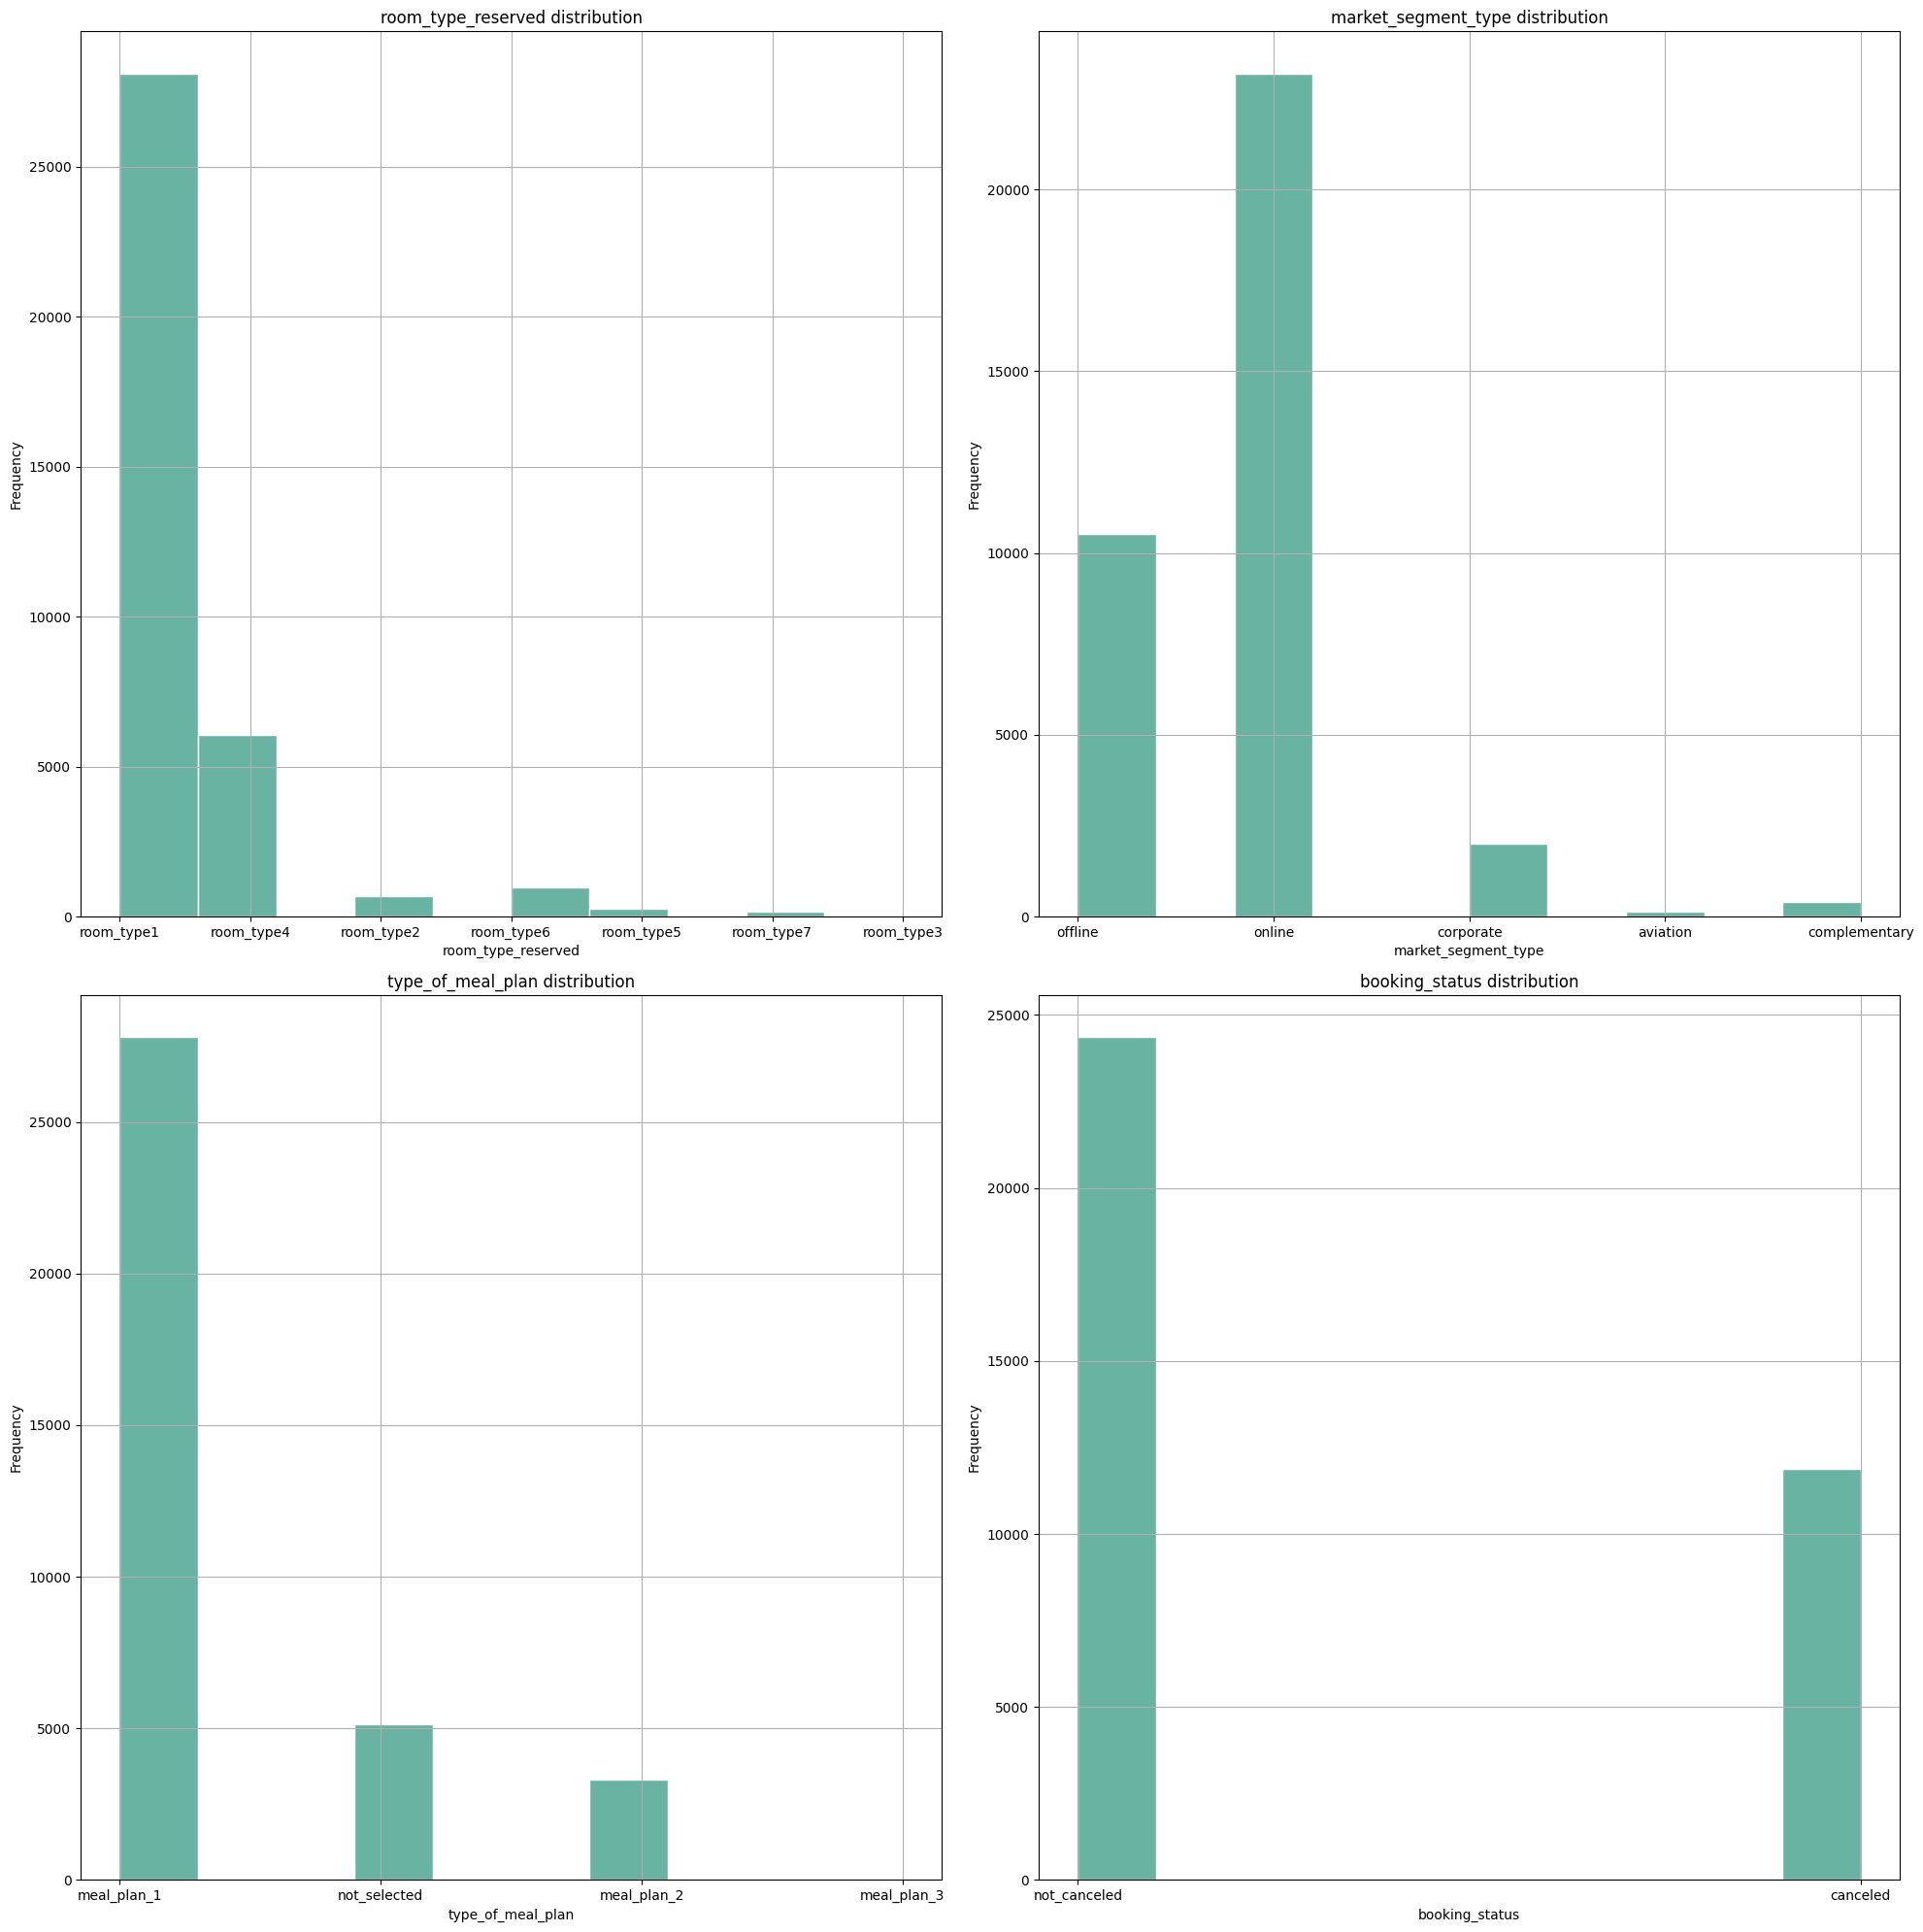

In [21]:
fig, axes = plt.subplots(2,2,figsize = (20, 20))
axes = axes.flatten()

for i, cat in enumerate(categorical):
    # Add the histogram
    data[cat].hist(ax=axes[i], # Define on which ax we're working on
                    edgecolor='white', # Color of the border
                    color='#69b3a2' # Color of the bins
                   )
    
    # Add title and axis label
    axes[i].set_title(f'{cat} distribution') 
    axes[i].set_xlabel(cat) 
    axes[i].set_ylabel('Frequency') 

plt.tight_layout()

# Show the plot
plt.show()

In [23]:
correlation_table = data[list(quantitative)].corr()
correlation_table

,avg_price_per_room,no_of_week_nights,required_car_parking_space,no_of_weekend_nights,repeated_guest,no_of_adults,no_of_previous_cancellations,no_of_special_requests,lead_time,no_of_children,no_of_previous_bookings_not_canceled
avg_price_per_room,1.000000,0.022771,0.061695,-0.004376,-0.174684,0.296560,-0.063323,0.184162,-0.062715,0.337505,-0.113539
no_of_week_nights,0.022771,1.000000,-0.049022,0.179474,-0.100295,0.105458,-0.030245,0.045801,0.149755,0.024120,-0.049387
required_car_parking_space,0.061695,-0.049022,1.000000,-0.031208,0.110452,0.011808,0.027176,0.087966,-0.066270,0.034466,0.063043
no_of_weekend_nights,-0.004376,0.179474,-0.031208,1.000000,-0.067362,0.103654,-0.020693,0.060670,0.046740,0.029489,-0.026391
repeated_guest,-0.174684,-0.100295,0.110452,-0.067362,1.000000,-0.192138,0.391246,-0.011804,-0.135918,-0.036247,0.538728
no_of_adults,0.296560,0.105458,0.011808,0.103654,-0.192138,1.000000,-0.047531,0.189101,0.097098,-0.020112,-0.118868
no_of_previous_cancellations,-0.063323,-0.030245,0.027176,-0.020693,0.391246,-0.047531,1.000000,-0.003284,-0.045786,-0.016375,0.468670
no_of_special_requests,0.184162,0.045801,0.087966,0.060670,-0.011804,0.189101,-0.003284,1.000000,-0.101840,0.124583,0.027230
lead_time,-0.062715,0.149755,-0.066270,0.046740,-0.135918,0.097098,-0.045786,-0.101840,1.000000,-0.046909,-0.077940
no_of_children,0.337505,0.024120,0.034466,0.029489,-0.036247,-0.020112,-0.016375,0.124583,-0.046909,1.000000,-0.021123


In [39]:
positive_correlations = {col:val for col, val in correlation_table[correlation_table != 1].max().items() if val > 0.15}

In [40]:
negative_correlations = {col:val for col, val in correlation_table[correlation_table != 1].min().items() if val < -0.062}

In [41]:
negative_correlations

{'avg_price_per_room': -0.17468437388564623,
 'no_of_week_nights': -0.10029472326407567,
 'required_car_parking_space': -0.0662697227736657,
 'no_of_weekend_nights': -0.06736245944197142,
 'repeated_guest': -0.19213789265920775,
 'no_of_adults': -0.19213789265920775,
 'no_of_previous_cancellations': -0.06332344285158195,
 'no_of_special_requests': -0.10183954267250957,
 'lead_time': -0.13591772082839493,
 'no_of_previous_bookings_not_canceled': -0.11886775148892385}

In [42]:
unique_positive_correlations = {}
unique_negative_correlations = {}

for col, val in positive_correlations.items():
    if col not in unique_positive_correlations.keys() and col not in unique_positive_correlations.values():
        unique_positive_correlations[col] = correlation_table[correlation_table[col] == val].index[0]
    
for col, val in negative_correlations.items():
    if col not in unique_negative_correlations.keys() and col not in unique_negative_correlations.values():
        unique_negative_correlations[col] = correlation_table[correlation_table[col] == val].index[0]

print(unique_positive_correlations)
print(unique_negative_correlations)

{'avg_price_per_room': 'no_of_children', 'no_of_week_nights': 'no_of_weekend_nights', 'repeated_guest': 'no_of_previous_bookings_not_canceled', 'no_of_adults': 'avg_price_per_room', 'no_of_previous_cancellations': 'no_of_previous_bookings_not_canceled', 'no_of_special_requests': 'no_of_adults'}
{'avg_price_per_room': 'repeated_guest', 'no_of_week_nights': 'repeated_guest', 'required_car_parking_space': 'lead_time', 'no_of_weekend_nights': 'repeated_guest', 'no_of_adults': 'repeated_guest', 'no_of_previous_cancellations': 'avg_price_per_room', 'no_of_special_requests': 'lead_time', 'no_of_previous_bookings_not_canceled': 'no_of_adults'}


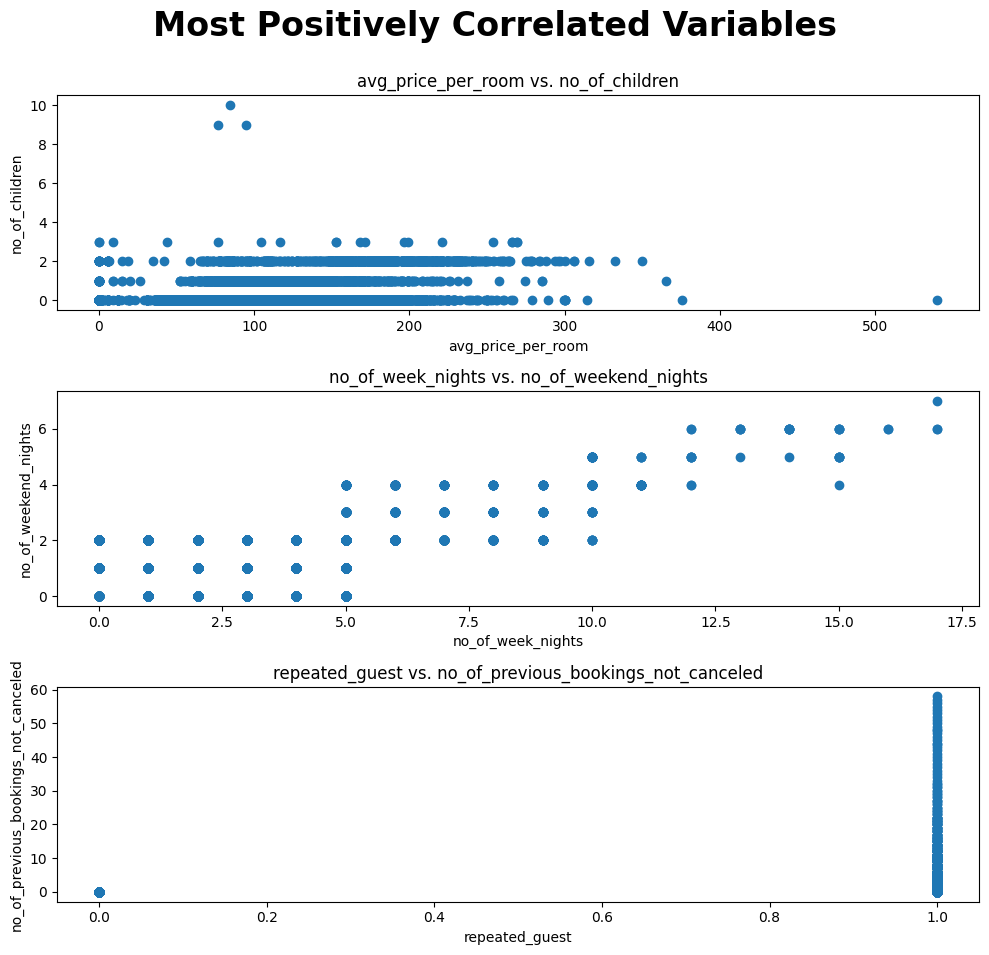

In [53]:
num_correlations = 3

fig, axes = plt.subplots(num_correlations,1,figsize = (10, 10))
axes = axes.flatten()

fig.suptitle('Most Positively Correlated Variables', fontsize = 24, fontweight = 'bold')

for i, (key, val) in enumerate(unique_positive_correlations.items()):
    if i < num_correlations:
        var1 = key
        var2 = val

        # Add the histogram
        axes[i].scatter(x=data[var1], y=data[var2])
        
        # Add title and axis label
        axes[i].set_title(f'{var1} vs. {var2}') 
        axes[i].set_xlabel(var1) 
        axes[i].set_ylabel(var2) 
    
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# Show the plot
plt.show()

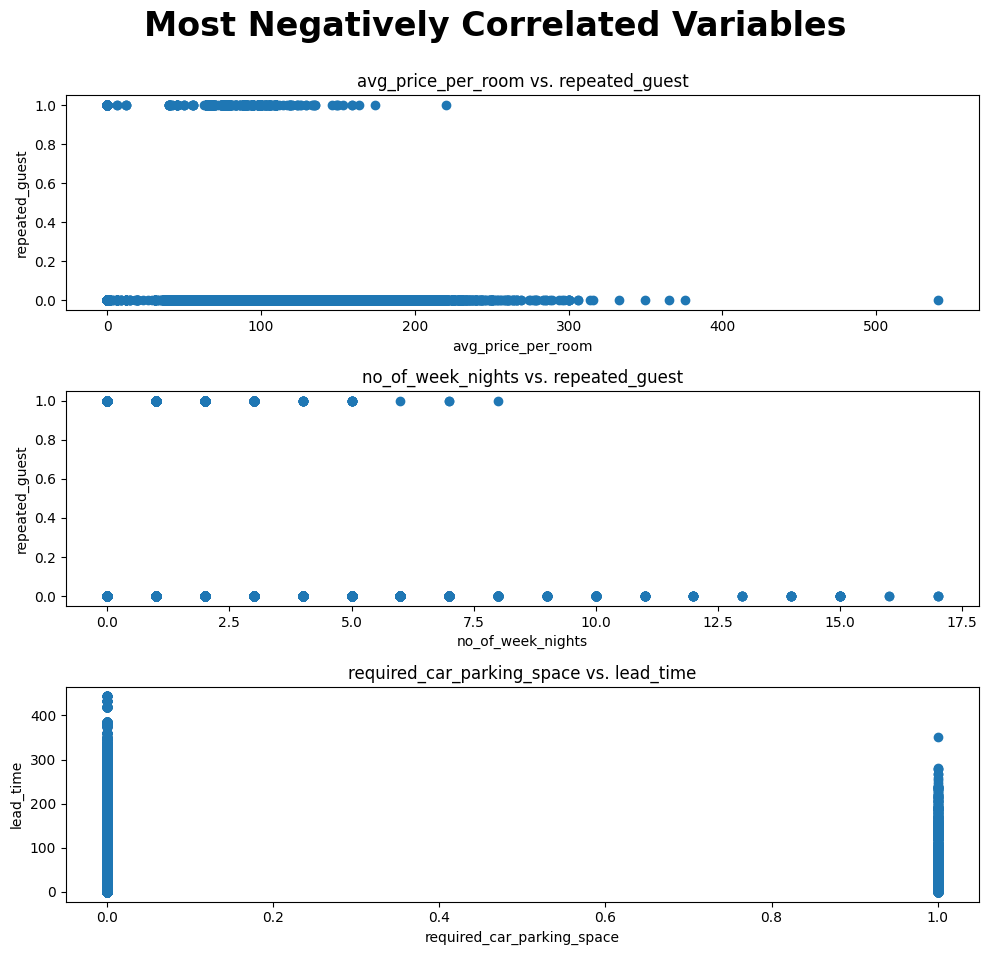

In [54]:
num_correlations = 3

fig, axes = plt.subplots(num_correlations,1,figsize = (10, 10))
axes = axes.flatten()

fig.suptitle('Most Negatively Correlated Variables', fontsize = 24, fontweight = 'bold')

for i, (key, val) in enumerate(unique_negative_correlations.items()):
    if i < num_correlations:
        var1 = key
        var2 = val

        # Add the histogram
        axes[i].scatter(x=data[var1], y=data[var2])
        
        # Add title and axis label
        axes[i].set_title(f'{var1} vs. {var2}') 
        axes[i].set_xlabel(var1) 
        axes[i].set_ylabel(var2) 
    
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# Show the plot
plt.show()